In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PARQUET = Path("../results/id_est/pythia/pythia_1.4b_flat_Rsmall_noise0p2_d30_n1024_s64_id.parquet")

METRICS = [
    ("twonn",        "TwoNN ID"),
    ("ess_a_k25",    "ESS-A (k=25)"),
    ("pca_curv_k25", "PCA curvature (k=25)"),
    ("entropy",      "Entropy"),
    ("nbh_size",     "Neighbourhood size"),
]

df = pd.read_parquet(PARQUET)
df.head(3)

,depth,pos,sample,twonn,entropy,ess_a_k25,pca_curv_k25,nbh_size
0,embed,0,0,22.874749,8.619656,27.960321,0.0,0.187081
1,embed,0,1,22.874749,9.095726,29.976177,0.0,0.159779
2,embed,0,2,22.874749,8.864209,28.935034,0.0,0.180249


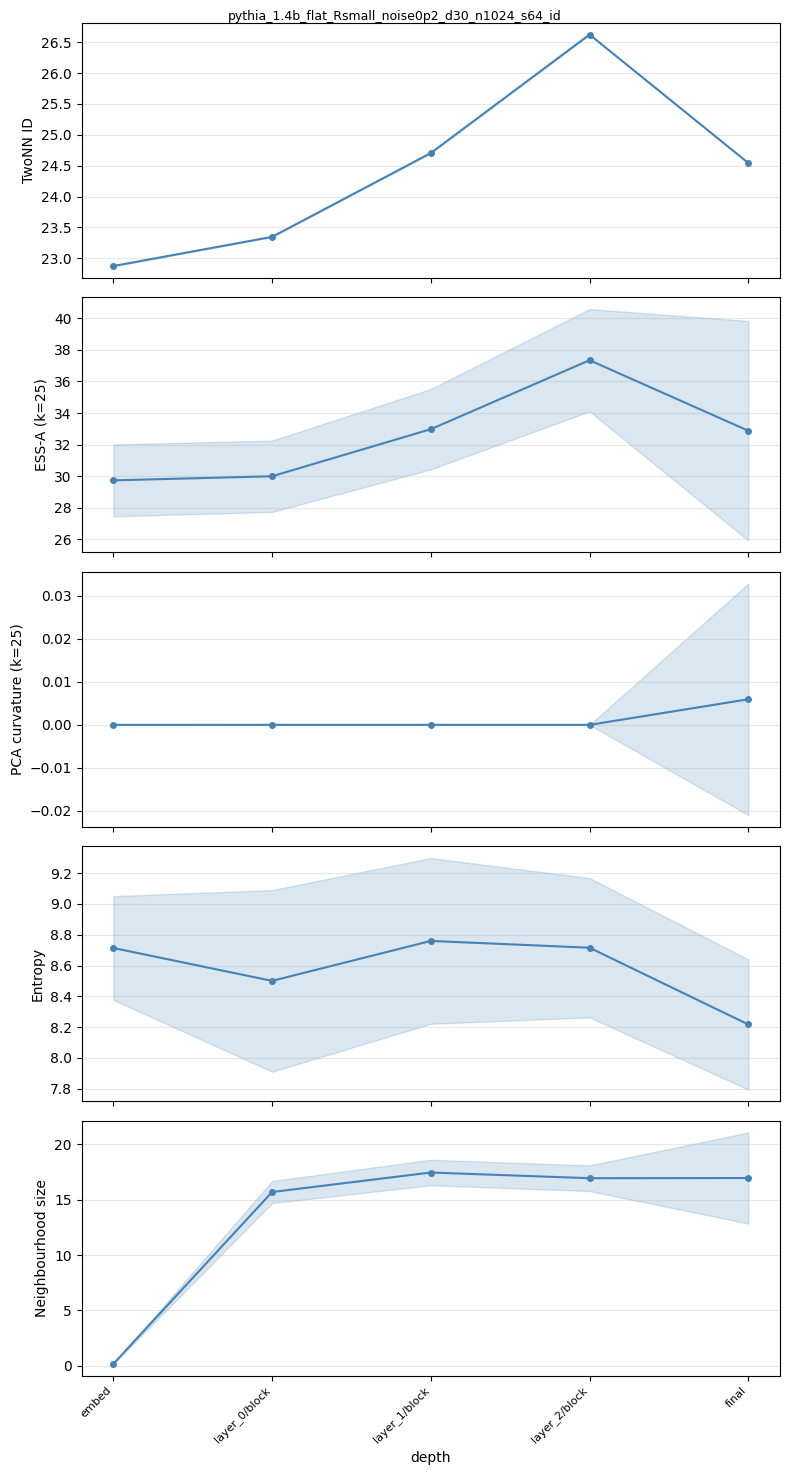

In [3]:
def depth_order(depths) -> list[str]:
    def key(d):
        if d == "embed":  return (-1, "")
        if d == "final":  return (10_000, "")
        parts = d.split("/")
        return (int(parts[0].split("_")[1]), parts[1] if len(parts) > 1 else "")
    return sorted(depths, key=key)

depths  = depth_order(df["depth"].unique())
metrics = [(col, lbl) for col, lbl in METRICS if col in df.columns]

agg = df.groupby("depth")[[col for col, _ in metrics]].agg(["mean", "std"])
x   = np.arange(len(depths))

fig, axes = plt.subplots(len(metrics), 1,
                         figsize=(max(8, len(depths) * 0.6), 3 * len(metrics)),
                         sharex=True)
if len(metrics) == 1:
    axes = [axes]

for ax, (col, lbl) in zip(axes, metrics):
    means = np.array([agg.loc[d, (col, "mean")] for d in depths])
    stds  = np.array([agg.loc[d, (col, "std")]  for d in depths])
    ax.plot(x, means, marker="o", markersize=4, color="steelblue")
    ax.fill_between(x, means - stds, means + stds, alpha=0.2, color="steelblue")
    ax.set_ylabel(lbl)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(depths, rotation=45, ha="right", fontsize=8)
axes[-1].set_xlabel("depth")

fig.suptitle(PARQUET.stem, fontsize=9)
fig.tight_layout()
plt.show()